In [3]:
from scripts.AbstractExperiments import ExperimentRunner
from scripts.TexTables import SaveDataFrameToTexTemplate
from copy import deepcopy
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

In [4]:
defaultConfig = {"Budget": 3, "Horizon": 6}
inputConfigs = {
    "(Hal)": {"Theories": [["Hal", "Utility", 0]], "Considerations": [["Hal", "Hal"]]},
    "(Carla)": {"Theories": [["Carla", "Utility", 0]], "Considerations": [["Carla", "Carla"]]},
    "(AU)": {"Theories": [["AU", "Utility", 0]], "Considerations": [["Overall", "AU"]]},
    "(Hal, Carla)": {"Theories": [["AU", "Utility", 0]], "Considerations": [["Hal", "AU"], ["Carla", "AU"]]},
    "(Hal)^0, (Carla)^0": {"Theories": [["Carla", "Utility", 0], ["Hal", "Utility", 0]], "Considerations": [["Carla", "Carla"], ["Hal", "Hal"]]},
    "(Hal)^0, (Carla)^0, (Hal,Carla)^0": {"Theories": [["Carla", "Utility", 0], ["Hal", "Utility", 0], ["AU", "Utility", 0]], "Considerations": [["Carla",["AU", "Carla"]], ["Hal", ["AU", "Hal"]]]},
    #"(HalLife)^0, (CarlaLife)^0": {"Theories": [["HalLife", "Utility", 0], ["CarlaLife", "Utility", 0]],
    #                "Considerations": [["CarlaLife", "CarlaLife"], ["HalLife", "HalLife"]]
    #},
    #"(HalLife)^0, (CaraLife)^0, (HalSmall)^1, (CaraSmall)^1": {
    #    "Theories": [["HalLife", "Utility", 0], ["CarlaLife", "Utility", 0], ["HalSmall", "Utility", 0], ["CarlaSmall", "Utility", 1]],
    #    "Considerations": [["CarlaLife", "CarlaLife"], ["HalLife", "HalLife"], ["CarlaSmall", "CarlaSmall"], ["HalSmall", "HalSmall"]]
    #}
}
Config_repetitions=1
Environment_repetitions = 10

In [5]:
configs = []
for name, dat in inputConfigs.items():
    c = deepcopy(defaultConfig)
    c["Name"] = name
    c["Theories"] = dat["Theories"]
    c["Considerations"] = dat["Considerations"]
    c["Budget"] = dat["Budget"] if "Budget" in dat.keys() else c["Budget"]
    c["Horizon"] = dat["Horizon"] if "Horizon" in dat.keys() else c["Horizon"]
    configs.append(c)

In [6]:
er = ExperimentRunner("LostInsulin", configs, MoralPlanner_Location="/../")
er.buildEnvironments(configRepetitions=1)
er.run(configRepetitions=Config_repetitions, envRepetitions=Environment_repetitions)

Written LostInsulin MMMDP with 689 states and theories [{'Name': 'Hal', 'Type': 'Utility', 'Rank': 0}].
PATH  /Users/user/Desktop/MyMoralPlanner/MoralPlanner/Notebooks/../Data/Experiments/LostInsulin/2026-06-21_18:47:13/mdps/(Hal)_con0.json

Written LostInsulin MMMDP with 689 states and theories [{'Name': 'Carla', 'Type': 'Utility', 'Rank': 0}].
PATH  /Users/user/Desktop/MyMoralPlanner/MoralPlanner/Notebooks/../Data/Experiments/LostInsulin/2026-06-21_18:47:13/mdps/(Carla)_con0.json

Written LostInsulin MMMDP with 689 states and theories [{'Name': 'AU', 'Type': 'Utility', 'Rank': 0}].
PATH  /Users/user/Desktop/MyMoralPlanner/MoralPlanner/Notebooks/../Data/Experiments/LostInsulin/2026-06-21_18:47:13/mdps/(AU)_con0.json

Written LostInsulin MMMDP with 689 states and theories [{'Name': 'AU', 'Type': 'Utility', 'Rank': 0}].
PATH  /Users/user/Desktop/MyMoralPlanner/MoralPlanner/Notebooks/../Data/Experiments/LostInsulin/2026-06-21_18:47:13/mdps/(Hal, Carla)_con0.json

Written LostInsulin MMMD

In [7]:
cols = ["Config_name", 'Hal_Utility', 'Carla_Utility', "Min_non_accept", "Num_of_min_non_accept", "Num_of_sols", "Total_time"]
df = pd.DataFrame(er.data)

df = df.replace(["", "N/A", "NA", "nan", "None"], np.nan)

if 'Carla' in df.columns and 'CarlaLife' in df.columns:
    df['Carla_Utility'] = df['Carla'].combine_first(df['CarlaLife'])

if 'Hal' in df.columns and 'HalLife' in df.columns:
    df['Hal_Utility'] = df['Hal'].combine_first(df['HalLife'])

if 'Overall' in df.columns:
    df['Hal_Utility'] = df['Hal_Utility'].combine_first(df['Overall'])

df['Config_name'] = df['Config_name'].str.replace("Hal", "H")
df['Config_name'] = df['Config_name'].str.replace("Carla", "C")

df['Hal_Utility'] = pd.to_numeric(df['Hal_Utility'])
df['Carla_Utility'] = pd.to_numeric(df['Carla_Utility'])
df['Hal_Utility'] = df['Hal_Utility'].round(3)
df['Carla_Utility'] = df['Carla_Utility'].round(3)
df = df.replace(np.nan, "SKIP")

agg_rules = {
            'Hal_Utility': 'first',
            'Carla_Utility': 'first',
            "Num_of_min_non_accept": 'first',
            "Num_of_sols": 'first',
            "Min_non_accept": 'first',
            'Total_time': 'mean',
        }
        

df = df[cols].groupby('Config_name', sort=False).agg(agg_rules)

SaveDataFrameToTexTemplate(df, f"{er.texTablesFolder}/UtilitarianResults.tex", f"{er.texOutFolder}/Utility_table.tex", row_template_mode=False)
df.head(10)

KeyError: 'Hal_Utility'

The following investigates the Hal=Carla experiment.

<Figure size 600x400 with 0 Axes>

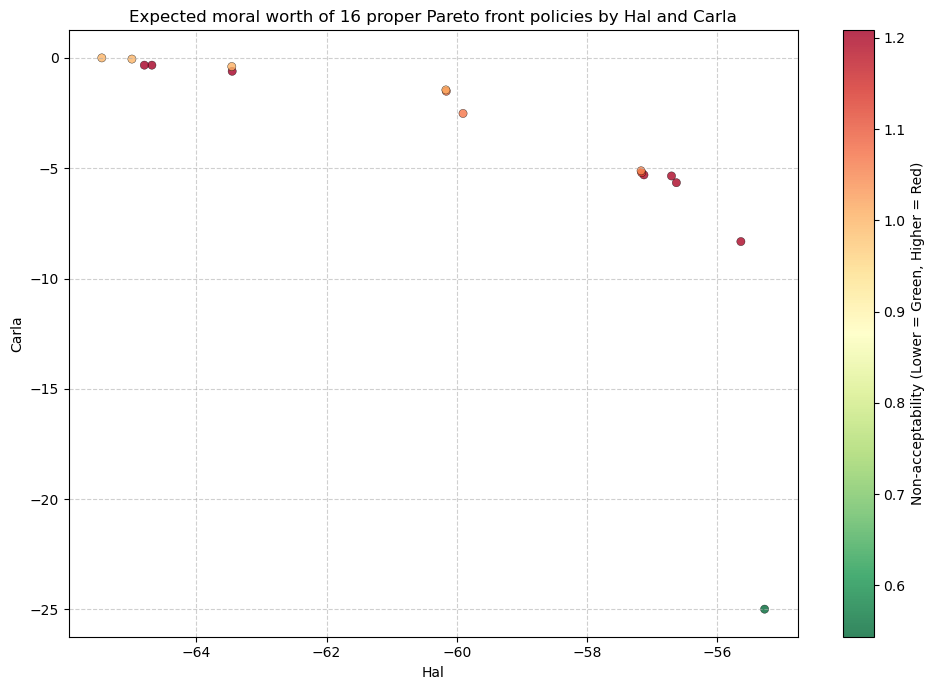

In [ ]:

# Load the Hal=Carla case
#configName = "(Hal, Carla)"
configName = "(Hal)^0, (Carla)^0"
con_one_label = "Hal"
con_two_label = "Carla"
plt.figure(figsize=(6,4))
er.plotParetoGraph(configName, 0, con_one_label, con_two_label, 0, f"{configName}_ParetoGraph.png")

In [ ]:
import re
cols = ["(Hal)", "(Carla)", "(Hal, Carla)", "(Hal)^0, (Carla)^0", "(Hal)^0, (Carla)^0, (Hal,Carla)^0"]
data = []
for c in cols:
    # Assuming self.makePlanOutFileName exists
    outFile = er.makePlanOutFileName(c, 0, 0)
    with open(outFile, 'r') as file:
        json_data = json.load(file)
        min_nacc = json_data["Solutions"][json_data["Solutions_Order"][0]]["Acceptability"]
        order_idx = 0
        for i in json_data["Solutions_Order"]:
            soln = json_data["Solutions"][i]
            if (soln["Acceptability"]!=min_nacc):
                break
            formatted_c = re.sub(r"\^(\d)", r"$^{\1}$", str(c))
            y = [formatted_c, order_idx]
            hal_key = "Hal"
            car_key = "Carla"
            if ("Life" in list(soln["Expectation"].keys())[0]):
                hal_key = "HalLife"
                car_key = "CarlaLife"

            if (hal_key in soln["Expectation"].keys()):
                y.append(soln["Expectation"][hal_key])
            else:
                y.append(0)

            if (car_key in soln["Expectation"].keys()):
                y.append(soln["Expectation"][car_key])
            else:
                y.append(0)

            data.append(y)
            order_idx += 1



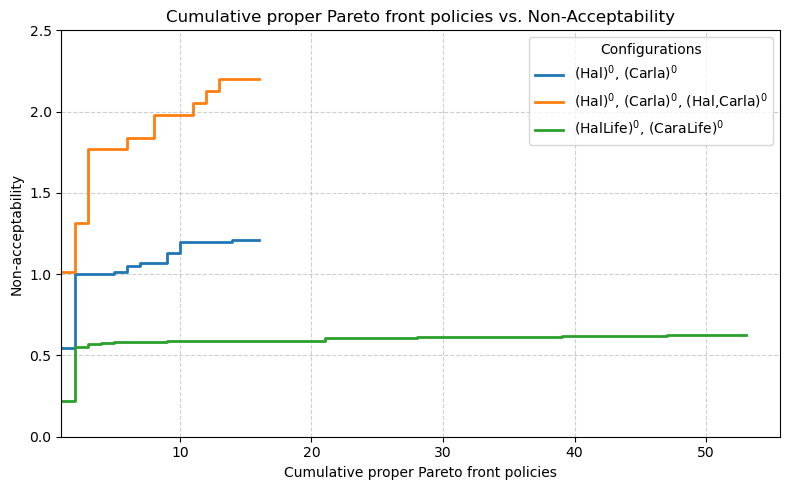

In [ ]:

plt.figure(figsize=(8, 5))

configs_names = ["(Hal)^0, (Carla)^0",
                 "(Hal)^0, (Carla)^0, (Hal,Carla)^0",
                 "(HalLife)^0, (CaraLife)^0"
                 ]
for c in configs_names:
    # Assuming self.makePlanOutFileName exists
    outFile = er.makePlanOutFileName(c, 0, 0)
    with open(outFile, 'r') as file:
        json_data = json.load(file)
        nacc = [sol["Acceptability"] for sol in json_data["Solutions"]]  
        x_sorted = np.sort(nacc)
        y_cumulative = np.arange(1, len(x_sorted) + 1)
        
        formatted_label = re.sub(r"\^(\d)", r"$^{\1}$", str(c))
        
        plt.step(y_cumulative, x_sorted, where='post', linewidth=2, label=formatted_label)

plt.title(f"Cumulative proper Pareto front policies vs. Non-Acceptability")
plt.ylabel("Non-acceptability")
plt.xlabel("Cumulative proper Pareto front policies")
plt.grid(True, linestyle='--', alpha=0.6)

plt.ylim(bottom=0, top=2.5) 
plt.xlim(left=1) 

plt.legend(title="Configurations")

plt.tight_layout()

plt.tight_layout()
plt.savefig(f"{er.figuresFolder}/Solution_Growth.png", dpi=300)
plt.show()



In [ ]:

configs_names = ["(Hal)", "(Carla)", "(Hal, Carla)", "(Hal)^0, (Carla)^0", 
                 "(Hal)^0, (Carla)^0, (Hal,Carla)^0", "(HalLife)^0, (CaraLife)^0",
                 "(HalLife)^0, (CaraLife)^0, (HalSmall)^1, (CaraSmall)^1"]

data = []
for c in configs_names:
    for env_rep in range(Environment_repetitions):
        # Assuming self.makePlanOutFileName exists
        outFile = er.makePlanOutFileName(c, 0, env_rep)
        with open(outFile, 'r') as file:
            json_data = json.load(file)
            data.append([c, env_rep, 
                            json_data["Duration_Heuristic"],
                            json_data["Duration_Plan"],
                            json_data["Duration_Sols"],
                            json_data["Duration_MEHR"],
                            json_data["Duration_Total"]])
df = pd.DataFrame(data, columns=["Config_name", "Env_rep", "Heuristic", "Plan", "Solution and Trajectory Extraction", "MEHR", "Total"])

NameError: name 'Environment_repetitions' is not defined

In [ ]:

import re
time_categories = ['Heuristic', 'Plan', 'Solution and Trajectory Extraction', 'MEHR', 'Total']

averages = df.groupby('Config_name', sort=False)[time_categories].mean()

fig, ax = plt.subplots(layout='constrained', figsize=(13, 6))

averages.plot.bar(ax=ax, width=0.8, rot=0)

for container in ax.containers:
    formatted_label = re.sub(r"\^(\d)", r"$^{\1}$", str(container))
    ax.bar_label(container, padding=3, fmt='%.1f')
    
ax.set_ylabel('Duration (microseconds)')
ax.set_xlabel('')
ax.set_title('CPU time on Utilitarian Lost Insulin problems')

ax.legend(loc='upper left', ncols=5)
ax.set_ylim(0, df['Total'].max() * 1.05)

plt.savefig(f"{er.figuresFolder}/TimeGraph.png", dpi=300)
plt.show()

NameError: name 'df' is not defined